In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('telco_cust.csv')
df.info()
print(df.describe())
df.nunique()

# Chechking missing values
print(df.isnull().sum())

# Total charge must be int
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()
print(df['TotalCharges'].isna().sum())
df = df.dropna(subset=['TotalCharges'])  # Because just 0.15%, so I removed it
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

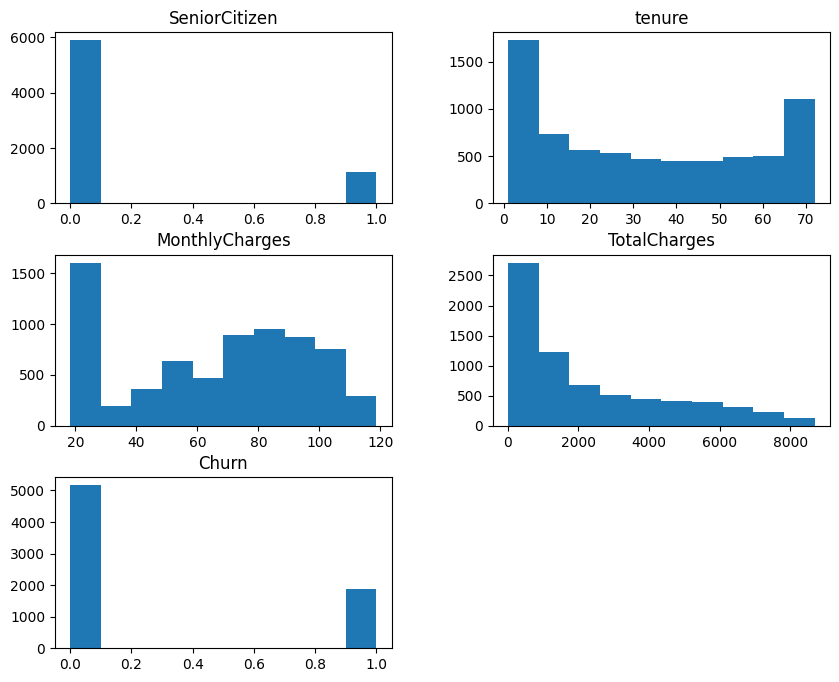

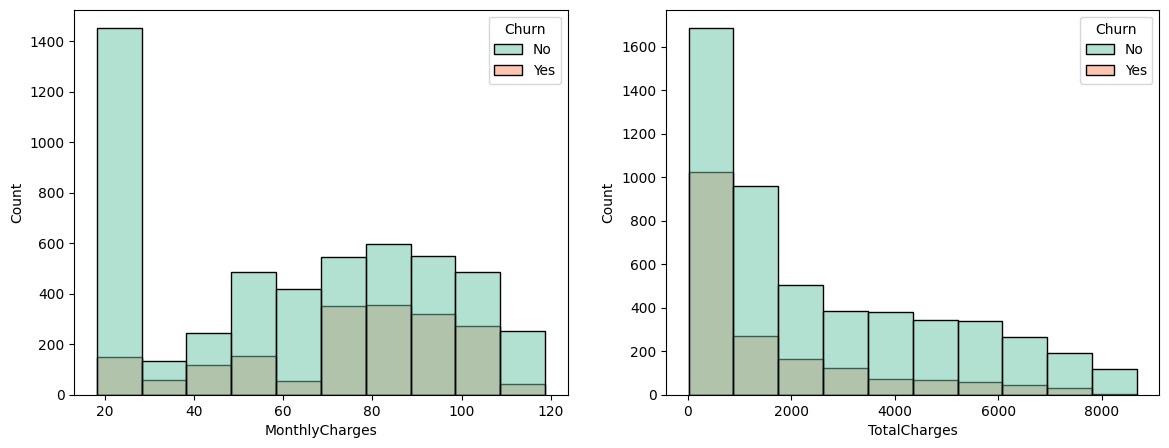

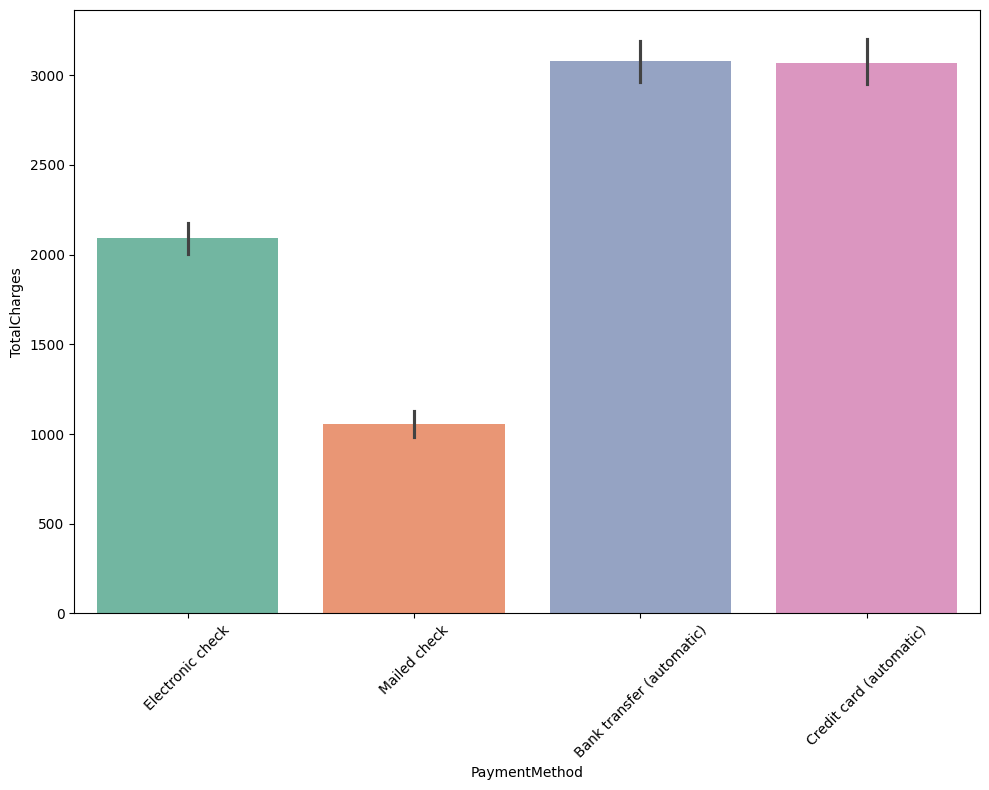

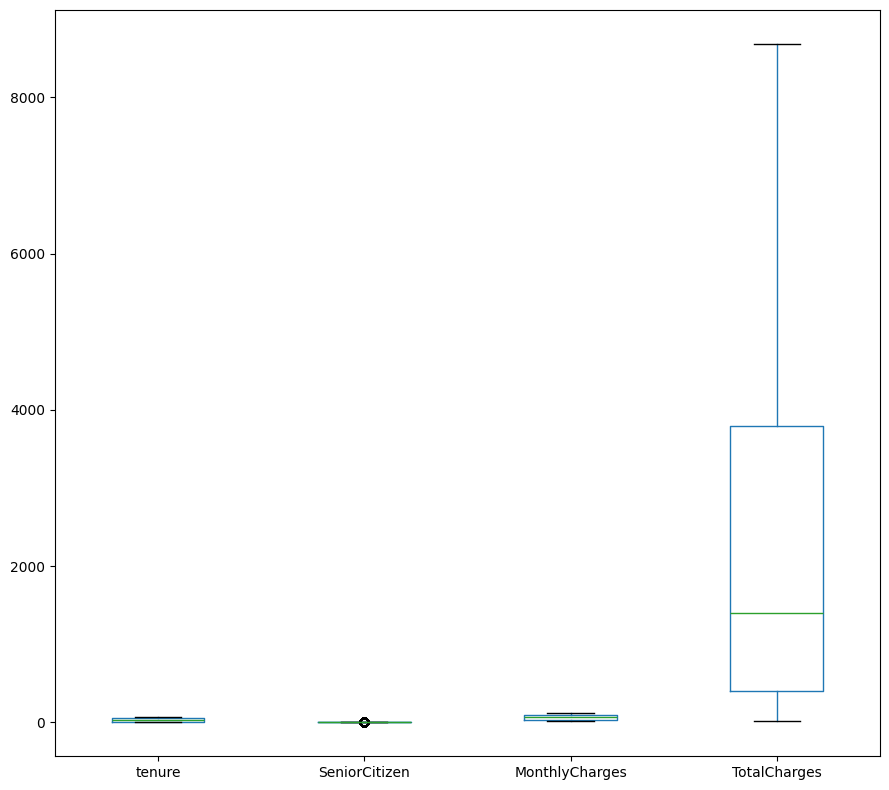

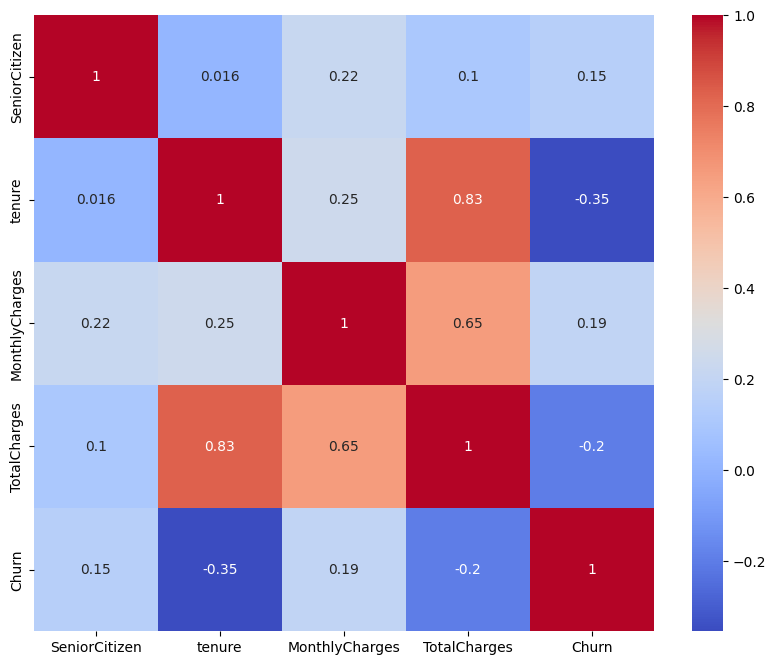

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Visualize
df.assign(Churn=df['Churn'].map({'Yes': 1, 'No': 0})).hist(bins=10, figsize=(10,8), grid=False)
plt.show()

# Visualize features vs churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, bins=10, hue='Churn', ax=ax, palette='Set2')
plt.show()

# Payment Method vs Total Charges
plt.figure(figsize=(10, 8)) 
sns.barplot(data=df, x='PaymentMethod', y='TotalCharges', palette='Set2')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

# Outliers chechking
plt.figure(figsize=(9, 8))
df.boxplot(column=['tenure', 'SeniorCitizen', 'MonthlyCharges', 'TotalCharges'], grid=False)
plt.tight_layout()
plt.show()

# Heatmap Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.assign(Churn=df['Churn'].map({'Yes': 1, 'No': 0})).select_dtypes(include='number').corr(),cmap='coolwarm', annot=True)
plt.show()

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import BernoulliNB

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Split data
x = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

# Separate column
cat_cols = x.select_dtypes(include=['object', 'category']).columns
num_cols = x.select_dtypes(include=['number']).columns

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('scaler', RobustScaler(), num_cols)
])

# Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=13),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=42, learning_rate=0.0018,max_iter=1000, max_depth=10),
    'Cat Booster': CatBoostClassifier(verbose=0,random_state=42, learning_rate=0.0018, max_depth=10),
    'SVC': SVC(random_state=42, max_iter=1000, kernel='rbf'),
    'Gausssian Process Classifier': GaussianProcessClassifier(random_state=42),
    'Bernoulli NB': BernoulliNB(),
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Pipeline
for name, method in models.items():
    main_pipeline = Pipeline(steps=[
        ('Preprocessor', preprocessor),
        ('Models', method)
    ])
    scores = cross_val_score(main_pipeline, x_train, y_train,cv=kf, scoring='accuracy')
    main_pipeline.fit(x_train, y_train)
    y_pred = main_pipeline.predict(x_test)

    # Evaluate
    print(name)
    print(f"Cross-Val Accuracy (Mean): {scores.mean():.4f} (+/- {scores.std():.4f})")
    print('Classification report:\n', classification_report(y_test, y_pred))

Logistic Regression
Cross-Val Accuracy (Mean): 0.8050 (+/- 0.0120)
Classification report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Random Forest
Cross-Val Accuracy (Mean): 0.8053 (+/- 0.0092)
Classification report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Hist Gradient Boosting
Cross-Val Accuracy (Mean): 0.8036 (+/- 0.0083)
Classification report:
               precision    recall  f1-score   support

           0       0.